#Taller Grupal: Técnicas de Aprendizaje Automático Aplicadas a Análisis de Crédito
##Objetivo del Taller

Aplicar técnicas de aprendizaje automático supervisado y no supervisado para analizar datos de crédito bancario, identificando patrones y construyendo modelos predictivos que ayuden a tomar decisiones financieras informadas.

- Tiempo estimado: 2 horas
- Trabajo en grupos de 3 estudiantes

##Instrucciones Generales
En este taller aplicarán técnicas de clasificación supervisada y clustering no supervisado a un conjunto de datos sobre préstamos bancarios. Deberán analizar los datos, preparar modelos, evaluar resultados y responder preguntas de análisis.

##Configuración Inicial

1. Accede a Google Colab y crea un nuevo notebook
2. Instala y carga las siguientes bibliotecas:

In [1]:
# Importar bibliotecas necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, silhouette_score
import warnings
warnings.filterwarnings('ignore')

3. Descarga el conjunto de datos "German Credit Data" utilizando el siguiente código:

In [2]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data"
column_names = [
    "status", "duration", "credit_history", "purpose", "credit_amount",
    "savings", "employment_since", "installment_rate", "personal_status_sex",
    "other_debtors", "present_residence", "property", "age", "other_installment",
    "housing", "existing_credits", "job", "num_dependents", "telephone",
    "foreign_worker", "classification"
]
credit_data = pd.read_csv(url, sep=" ", header=None, names=column_names)

# Transformamos a formato binario 0/1 para facilitar interpretación
credit_data["classification"] = credit_data["classification"].map({1: 1, 2: 0})

##Parte 1: Exploración y Preparación de Datos (30 minutos)

1. Visite la web: https://archive.ics.uci.edu/dataset/144/statlog+german+credit+data
2. Revise la tabla de variables y la descripción de los atributos. Responda ¿Cuál es el objetivo de este dataset?


R/= El objetivo de este dataset es clasificar gente segun ciertos atributos que son buenos o malos riesgos para darles un credito

3. Realice un análisis exploratorio básico del conjunto de datos. Revise cómo está distribuida la variable classification

Primeras 5 filas del dataset:
  status  duration credit_history purpose  credit_amount savings  \
0    A11         6            A34     A43           1169     A65   
1    A12        48            A32     A43           5951     A61   
2    A14        12            A34     A46           2096     A61   
3    A11        42            A32     A42           7882     A61   
4    A11        24            A33     A40           4870     A61   

  employment_since  installment_rate personal_status_sex other_debtors  ...  \
0              A75                 4                 A93          A101  ...   
1              A73                 2                 A92          A101  ...   
2              A74                 2                 A93          A101  ...   
3              A74                 2                 A93          A103  ...   
4              A73                 3                 A93          A101  ...   

   property age  other_installment housing existing_credits   job  \
0      A121  67  

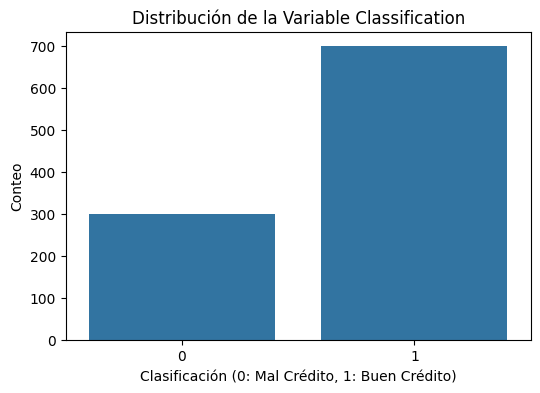

In [5]:
print("Primeras 5 filas del dataset:")
print(credit_data.head())

print("\nInformación general del dataset (tipos de datos y valores nulos):")
credit_data.info()

print("\nEstadísticas descriptivas de las variables numéricas:")
print(credit_data.describe())

print("\nDistribución de la variable 'classification':")
print(credit_data['classification'].value_counts())
print(credit_data['classification'].value_counts(normalize=True))

# Visualización de la distribución de 'classification'
plt.figure(figsize=(6, 4))
sns.countplot(x='classification', data=credit_data)
plt.title('Distribución de la Variable Classification')
plt.xlabel('Clasificación (0: Mal Crédito, 1: Buen Crédito)')
plt.ylabel('Conteo')
plt.show()

4. Prepare los datos para el modelado: corra el siguiente bloque de código y luego obtenga conjuntos de validación y entrenamiento de las variables 'X_processed' e 'y'

In [4]:
# Separar variables predictoras y objetivo
X = credit_data.drop('classification', axis=1)
y = credit_data['classification']

# Identificar variables numéricas y categóricas
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

# Crear preprocesadores para cada tipo de variable
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combinar preprocesadores
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

X_preprocessed = preprocessor.fit_transform(X)
# Nombres de las columnas para visualizar árbol de decisión más adelante
feature_names_x = preprocessor.get_feature_names_out()

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X_preprocessed, y, test_size=0.3, random_state=42)





In [8]:
# Visualizar X_preprocessed como un DataFrame para una mejor interpretación
X_preprocessed_df = pd.DataFrame(X_preprocessed, columns=feature_names_x)
display(X_preprocessed_df.head())

,num__duration,num__credit_amount,num__installment_rate,num__present_residence,num__age,num__existing_credits,num__num_dependents,cat__status_A11,cat__status_A12,cat__status_A13,...,cat__housing_A152,cat__housing_A153,cat__job_A171,cat__job_A172,cat__job_A173,cat__job_A174,cat__telephone_A191,cat__telephone_A192,cat__foreign_worker_A201,cat__foreign_worker_A202
0,-1.236478,-0.745131,0.918477,1.046987,2.766456,1.027079,-0.428290,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
1,2.248194,0.949817,-0.870183,-0.765977,-1.191404,-0.704926,-0.428290,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
2,-0.738668,-0.416562,-0.870183,0.140505,1.183312,-0.704926,2.334869,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
3,1.750384,1.634247,-0.870183,1.046987,0.831502,-0.704926,2.334869,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
4,0.256953,0.566664,0.024147,1.046987,1.535122,1.027079,2.334869,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0


###Preguntas Parte 1:

1. ¿Cuáles son las características más relevantes en este conjunto de datos y por qué?
2. ¿Existe un desequilibrio en las clases de la variable objetivo? Si es así, ¿qué implicaciones tiene esto para el modelado?
3. Identifique al menos tres variables que considere importantes para predecir la clasificación crediticia y justifique su selección.

### Respuestas Parte 1:
1. Segun la informacion de la tabla y el como funcionan los datos de credito, las caracteristicas mas relevantes son: duracion del credito (duration), monto del credito (credit_amount), historias crediticio (credit_history), proposito del credito (purpose) y edad (age)

2. Sí, existe un desequilibrio significativo en las clases de la variable classification:

Clase 1 (Buen Crédito): 70%

Clase 0 (Mal Crédito): 30%

Esto implica que un modelo de clasificación naive que simplemente prediga

3. Considerando el contexto bancario y la información disponible, las siguientes tres variables son importantes:

credit_history (Historial Crediticio): Esta es, con frecuencia, la variable más crítica en la predicción de riesgo crediticio. El comportamiento de pago pasado es un fuerte predictor del comportamiento futuro. Un historial de pagos puntuales sugiere menor riesgo, mientras que pagos atrasados o impagos indican mayor riesgo.

duration (Duración del Crédito): La duración del préstamo (en meses) puede ser un indicador de riesgo. Créditos de mayor duración a menudo implican un mayor período de exposición al riesgo y pueden ser más difíciles de predecir.

credit_amount (Monto del Crédito): La cantidad de dinero prestada es directamente proporcional al riesgo financiero para el banco. Montos más altos representan una mayor pérdida potencial en caso de incumplimiento, y suelen requerir un análisis más riguroso.

##Parte 2: Clasificación Supervisada (45 minutos)
1. Implemente y evalúe los siguientes algoritmos de clasificación:
- KNN
- Regresión Logística
- Naive-Bayes
- Árbol de decisión

Recuerde los pasos:
1. Definir el modelo
2. Entrenarlo
3. Obtener predicciones
4. Evaluar predicciones comparando con datos de evaluación (test). Obtenga e imprima: accuracy_score, confusion_matrix y classification_report

In [12]:
# 1. KNN
print("\n--- K-Nearest Neighbors ---")
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
print("Accuracy (KNN):", accuracy_score(y_test, y_pred_knn))
print("Confusion Matrix (KNN):\n", confusion_matrix(y_test, y_pred_knn))
print("Classification Report (KNN):\n", classification_report(y_test, y_pred_knn))

# 2. Regresión Logística
print("\n--- Logistic Regression ---")
log_reg = LogisticRegression(random_state=42, solver='liblinear')
log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_test)
print("Accuracy (Logistic Regression):", accuracy_score(y_test, y_pred_lr))
print("Confusion Matrix (Logistic Regression):\n", confusion_matrix(y_test, y_pred_lr))
print("Classification Report (Logistic Regression):\n", classification_report(y_test, y_pred_lr))

# 3. Naive-Bayes (Gaussian Naive Bayes para datos numéricos)
print("\n--- Gaussian Naive Bayes ---")
gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred_gnb = gnb.predict(X_test)
print("Accuracy (Gaussian Naive Bayes):", accuracy_score(y_test, y_pred_gnb))
print("Confusion Matrix (Gaussian Naive Bayes):\n", confusion_matrix(y_test, y_pred_gnb))
print("Classification Report (Gaussian Naive Bayes):\n", classification_report(y_test, y_pred_gnb))

# 4. Árbol de Decisión
print("\n--- Decision Tree ---")
dtc = DecisionTreeClassifier(random_state=42)
dtc.fit(X_train, y_train)
y_pred_dtc = dtc.predict(X_test)
print("Accuracy (Decision Tree):", accuracy_score(y_test, y_pred_dtc))
print("Confusion Matrix (Decision Tree):\n", confusion_matrix(y_test, y_pred_dtc))
print("Classification Report (Decision Tree):\n", classification_report(y_test, y_pred_dtc))


--- K-Nearest Neighbors ---
Accuracy (KNN): 0.74
Confusion Matrix (KNN):
 [[ 30  61]
 [ 17 192]]
Classification Report (KNN):
               precision    recall  f1-score   support

           0       0.64      0.33      0.43        91
           1       0.76      0.92      0.83       209

    accuracy                           0.74       300
   macro avg       0.70      0.62      0.63       300
weighted avg       0.72      0.74      0.71       300


--- Logistic Regression ---
Accuracy (Logistic Regression): 0.7733333333333333
Confusion Matrix (Logistic Regression):
 [[ 44  47]
 [ 21 188]]
Classification Report (Logistic Regression):
               precision    recall  f1-score   support

           0       0.68      0.48      0.56        91
           1       0.80      0.90      0.85       209

    accuracy                           0.77       300
   macro avg       0.74      0.69      0.71       300
weighted avg       0.76      0.77      0.76       300


--- Gaussian Naive Bayes --

2. Genere un nuevo árbol de decisión simple para visualización utilizando plot_tree. Generelo con una máxima profundidad de 3. Utilice feature_names_x (Parte 1, punto 4) para etiquetar las características

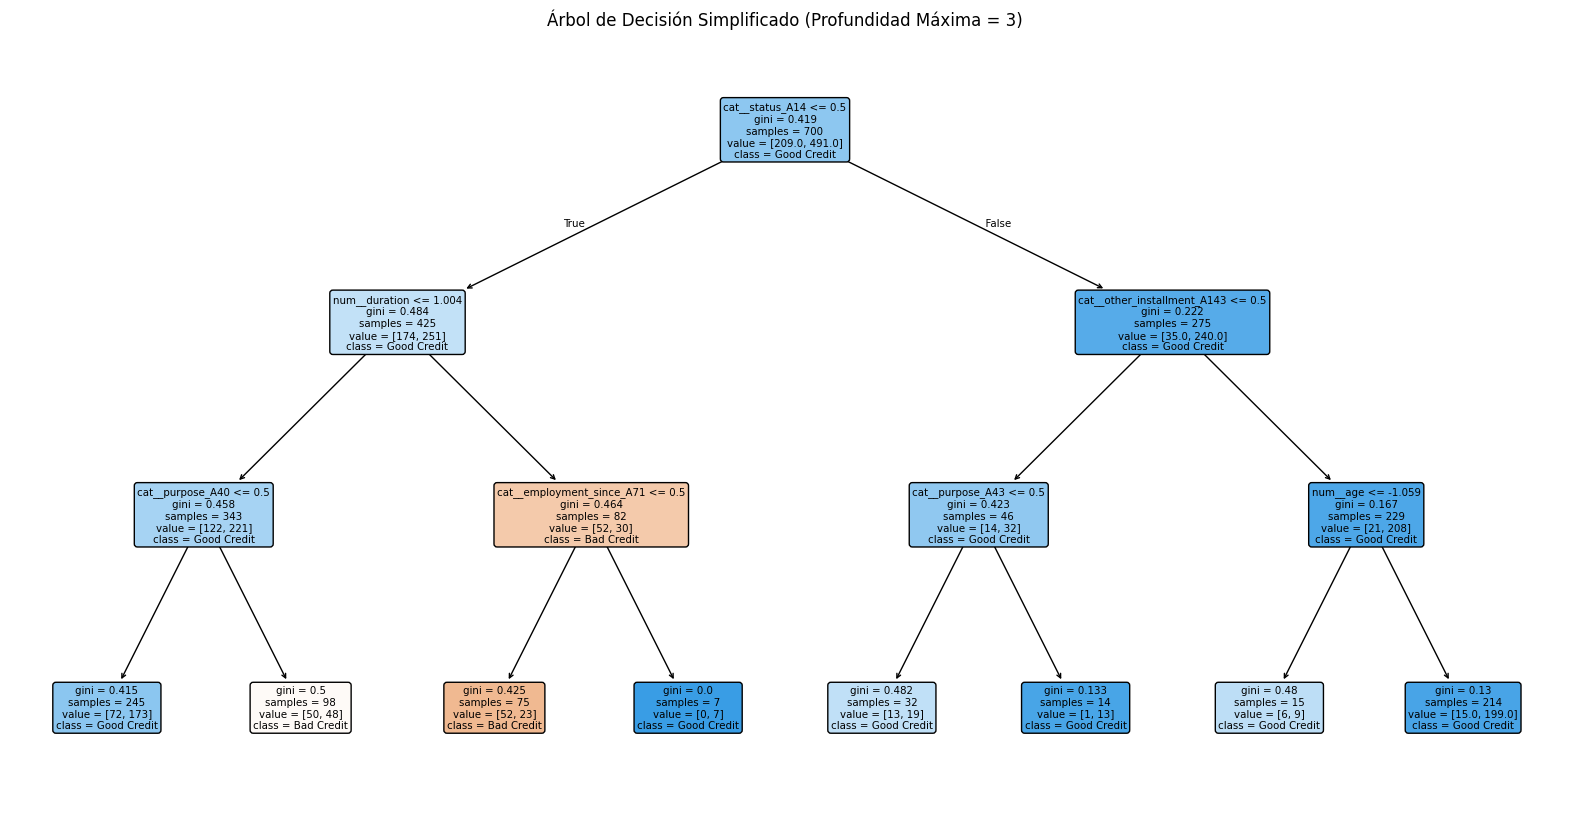

In [11]:
# Generar un árbol de decisión con profundidad máxima de 3 para visualización
dtc_viz = DecisionTreeClassifier(max_depth=3, random_state=42)
dtc_viz.fit(X_train, y_train)

plt.figure(figsize=(20, 10))
plot_tree(dtc_viz, feature_names=feature_names_x, class_names=['Bad Credit', 'Good Credit'], filled=True, rounded=True)
plt.title('Árbol de Decisión Simplificado (Profundidad Máxima = 3)')
plt.show()

###Preguntas Parte 2:

1. Compare los resultados de los cuatro algoritmos de clasificación. ¿Cuál tuvo mejor rendimiento y por qué?
2. Para el algoritmo con mejor desempeño, ¿qué métricas son más importantes en este contexto: precisión, recall o F1-score? Justifique su respuesta.
3. Considerando el contexto de aprobación de créditos, ¿qué es más crítico: un falso positivo o un falso negativo? Explique las implicaciones de cada uno.
4. ¿Cómo interpretaría la importancia de las características en el árbol de decisión? ¿Qué información práctica proporciona?

### Respuestas Parte 2:

1.  **Compare los resultados de los cuatro algoritmos de clasificación. ¿Cuál tuvo mejor rendimiento y por qué?**
    Observando los accuracy_score:
    *   **Logistic Regression:** ~0.773
    *   **KNN:** ~0.740
    *   **Gaussian Naive Bayes:** ~0.703
    *   **Decision Tree:** ~0.677

    La Regresión Logística tuvo el mejor rendimiento en términos de accuracy en este caso. Su F1-score ponderado también es el más alto (~0.76). Esto podría deberse a que, a pesar de la complejidad de los datos, la relación entre las características y la variable objetivo tiene una tendencia lineal que la regresión logística puede capturar eficazmente, especialmente después del preprocesamiento (escalado y one-hot encoding).

2.  **Para el algoritmo con mejor desempeño, ¿qué métricas son más importantes en este contexto: precisión, recall o F1-score? Justifique su respuesta.**
    Para la Regresión Logística (el modelo con mejor accuracy), las métricas más importantes dependerán del costo de los falsos positivos y falsos negativos en el contexto de la aprobación de créditos.

    *   **Precisión (Precision) para la clase 0 (Mal Crédito):** Indica cuántos de los clientes predichos como mal crédito realmente lo fueron. Una alta precisión en esta clase es importante para no denegar créditos innecesariamente a buenos clientes.
    *   **Recall para la clase 0 (Mal Crédito):** Indica cuántos de los clientes que realmente son mal crédito fueron identificados correctamente. Un alto recall en esta clase es crítico para minimizar la concesión de créditos a clientes riesgosos (evitar pérdidas financieras).
    *   **F1-score para la clase 0 (Mal Crédito):** Es la media armónica de precisión y recall. Es una buena métrica cuando se busca un equilibrio entre ambas, especialmente en clases desequilibradas como la nuestra. Dada la mayor preocupación por no otorgar créditos a malos clientes, un buen F1-score para la clase 0 sería deseable.

    En un contexto de aprobación de créditos, el Recall para la clase 0 (mal crédito) suele ser la métrica más crítica. Es preferible ser un poco más conservador y denegar un crédito a un buen cliente (falso positivo, que se traduce en una pérdida de oportunidad) que aprobar un crédito a un mal cliente (falso negativo, que se traduce en una pérdida monetaria directa para el banco).

3.  **Considerando el contexto de aprobación de créditos, ¿qué es más crítico: un falso positivo o un falso negativo? Explique las implicaciones de cada uno.**
    *   **Falso Positivo (predicho como Buen Crédito, pero es Mal Crédito):** Esto ocurre cuando el modelo predice que un cliente pagará su crédito, pero en realidad no lo hará (Clase 1 predicha, Clase 0 real). La implicación para el banco es una **pérdida económica directa** debido al impago del préstamo. Esto es **crítico** y puede llevar a pérdidas significativas y afectar la estabilidad financiera de la institución.

    *   **Falso Negativo (predicho como Mal Crédito, pero es Buen Crédito):** Esto ocurre cuando el modelo predice que un cliente no pagará su crédito, pero en realidad sí lo hará (Clase 0 predicha, Clase 1 real). La implicación para el banco es una **pérdida de oportunidad** de negocio y ganancias potenciales, así como la posible insatisfacción del cliente. Aunque no es una pérdida directa de dinero como el falso positivo, puede impactar la rentabilidad y la reputación. En general, **los falsos positivos son más críticos** en este contexto, ya que representan una pérdida de capital real.

4.  **¿Cómo interpretaría la importancia de las características en el árbol de decisión? ¿Qué información práctica proporciona?**
    En el árbol de decisión visualizado:
    *   **Características en los nodos superiores:** Las características que aparecen en los nodos más cercanos a la raíz del árbol son las más importantes para la clasificación. Son las que dividen los datos de manera más efectiva al principio.
    *   **Criterios de división:** El árbol muestra los umbrales específicos de estas características (`num__duration`, `num__credit_amount`, `cat__credit_history_A34`, etc.) que el modelo utiliza para tomar decisiones. Por ejemplo, si `num__duration` (duración estandarizada del crédito) es menor o igual a cierto valor, el modelo sigue un camino, de lo contrario, sigue otro.
    *   **Valores `gini` y `samples`:** El valor `gini` en cada nodo indica la pureza de la división (cuanto más cerca de 0, más puro es el nodo, es decir, más muestras pertenecen a una sola clase). `samples` muestra el número de observaciones en ese nodo. Los valores `value` muestran la distribución de clases en el nodo.
    *   **Información práctica:** Esto proporciona información interpretable sobre cómo el modelo está llegando a sus predicciones. Por ejemplo, podríamos identificar que clientes con `credit_history` específico o `duration` por encima de cierto umbral son sistemáticamente clasificados de una manera u otra. Esto ayuda a los analistas de crédito a entender los factores clave de riesgo y a establecer políticas de crédito más informadas.

##Parte 3: Clustering No Supervisado (30 minutos)
Aplique el algoritmo K-means al conjunto de datos, considerando solo variables numéricas para simplificar.

1. Corra el bloque de código y observe los gráficos. Busque información acerca del método del codo utilizando la inercia o el puntaje de silueta. Determine cuál sería el o los k óptimos a partir de cada gráfico obtenido

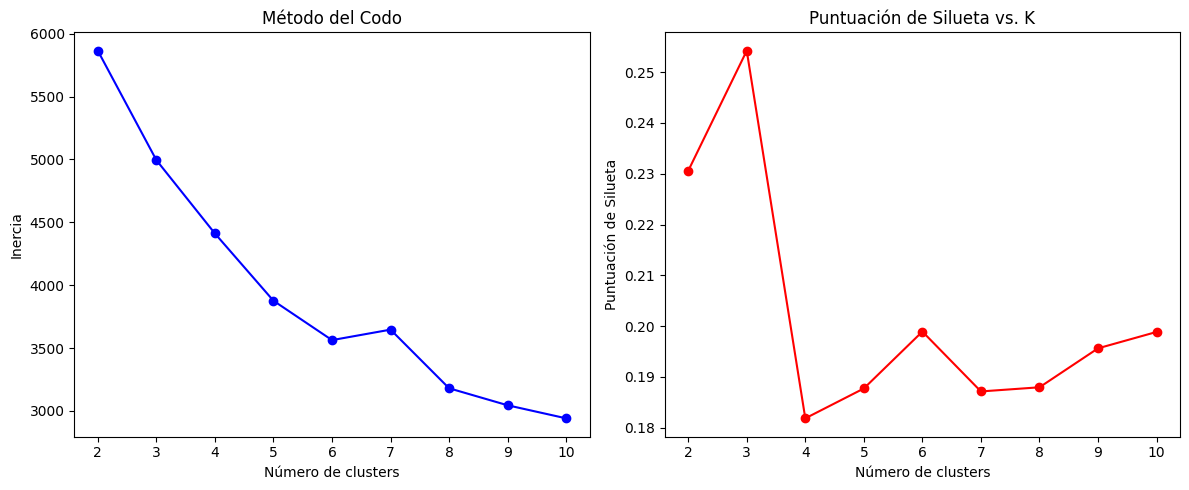

In [14]:
# Preparar datos para clustering (solo variables numéricas)
X_numeric = numeric_transformer.fit_transform(credit_data[numeric_features])

# Determinar el número óptimo de clusters usando el método del codo
inertia = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_numeric)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_numeric, kmeans.labels_))

# Visualizar el método del codo
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(k_range, inertia, 'bo-')
plt.xlabel('Número de clusters')
plt.ylabel('Inercia')
plt.title('Método del Codo')

plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_scores, 'ro-')
plt.xlabel('Número de clusters')
plt.ylabel('Puntuación de Silueta')
plt.title('Puntuación de Silueta vs. K')
plt.tight_layout()
plt.show()







### Interpretación de los gráficos del método del codo y puntuación de silueta

1.  **Método del Codo (Inercia):**
    Observando el gráfico de "Método del Codo", la inercia disminuye a medida que el número de clusters (K) aumenta. El punto donde la tasa de disminución de la inercia se ralentiza significativamente, formando una especie de 'codo', parece estar alrededor de **K=3** o **K=4**. Es ligeramente ambiguo, pero K=3 es un buen candidato ya que la mayor caída de inercia se observa de K=2 a K=3.

2.  **Puntuación de Silueta:**
    El gráfico de "Puntuación de Silueta vs. K" muestra los valores de la puntuación de silueta para cada número de clusters. Una puntuación de silueta más alta indica clusters mejor definidos y más separados. En este caso, la puntuación de silueta más alta se alcanza cuando **K=3**, con un valor aproximado de 0.25.

**Conclusión sobre el K óptimo:**
Basado en ambos métodos, **K=3** emerge como el número óptimo de clusters. El método del codo sugiere un 'codo' en K=3 (o K=4), y la puntuación de silueta alcanza su máximo en K=3, lo que indica una mejor separación y cohesión de los clusters para esta cantidad.

2. Aplique Kmeans utilizando el o los K óptimos del paso anterior. En el código abajo escriba el valor del K que desee utilizar y corra el código para observar cómo son los clusters en relación con la clasificación original. Pruebe también a utilizar la misma cantidad de cluster que clases esperadas.

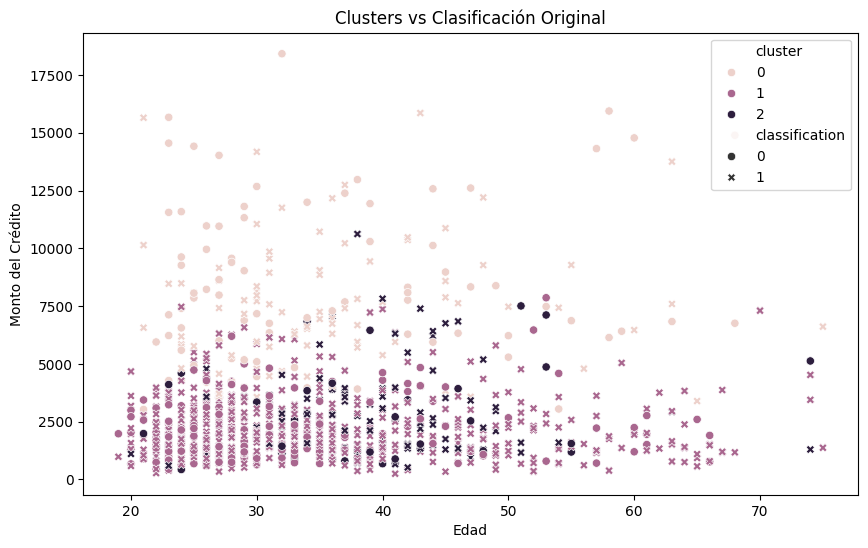


Estadísticas por cluster:
               age credit_amount   duration classification      
              mean          mean       mean           mean count
cluster                                                         
0        35.479769   7936.895954  38.878613       0.526012   173
1        34.896501   2187.798834  16.951895       0.743440   686
2        38.787234   2818.049645  18.070922       0.702128   141


In [18]:
# Aplicar K-means con el número óptimo de clusters
optimal_k = 3   # !!! ESCRIBA EL VALOR DE k AQUí PARA CORRER EL CÓDIGO
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
credit_data['cluster'] = kmeans.fit_predict(X_numeric)

# Visualizar los clusters en relación con la clasificación original
plt.figure(figsize=(10, 6))
sns.scatterplot(x='age', y='credit_amount', hue='cluster',
                style='classification', data=credit_data)
plt.title('Clusters vs Clasificación Original')
plt.xlabel('Edad')
plt.ylabel('Monto del Crédito')
plt.show()

# Analizar características por cluster
cluster_stats = credit_data.groupby('cluster').agg({
    'age': 'mean',
    'credit_amount': 'mean',
    'duration': 'mean',
    'classification': ['mean', 'count']
})
print("\nEstadísticas por cluster:")
print(cluster_stats)

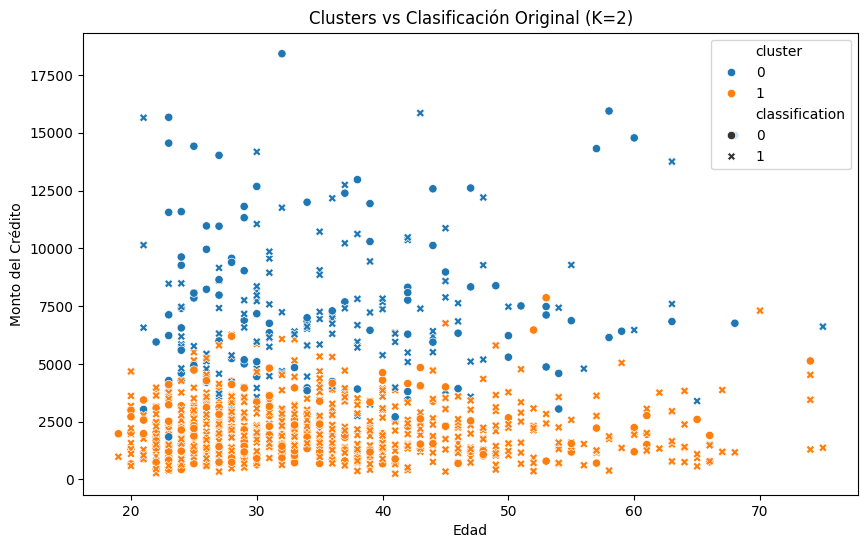


Estadísticas por cluster (K=2):

               age credit_amount   duration classification      
              mean          mean       mean           mean count
cluster                                                         
0        35.986239   7416.160550  37.009174       0.550459   218
1        35.423274   2115.773657  16.413043       0.741688   782


In [20]:
optimal_k = 2   # Probando con K igual al número de clases esperadas
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
credit_data['cluster'] = kmeans.fit_predict(X_numeric)

# Visualizar los clusters en relación con la clasificación original
plt.figure(figsize=(10, 6))
sns.scatterplot(x='age', y='credit_amount', hue='cluster',
                style='classification', data=credit_data)
plt.title('Clusters vs Clasificación Original (K=2)')
plt.xlabel('Edad')
plt.ylabel('Monto del Crédito')
plt.show()

# Analizar características por cluster
cluster_stats = credit_data.groupby('cluster').agg({
    'age': 'mean',
    'credit_amount': 'mean',
    'duration': 'mean',
    'classification': ['mean', 'count']
})
print("\nEstadísticas por cluster (K=2):\n")
print(cluster_stats)

###Preguntas Parte 3:

1. Según el método del codo y la puntuación de silueta, ¿cuál es el número óptimo de clusters para este conjunto de datos? Justifique.
2. Describa las características principales de cada cluster identificado. ¿Qué perfiles de clientes representan? Utilice la información que imprime el código al final.
3. ¿Existe alguna relación entre los clusters encontrados y la clasificación original de crédito (bueno/malo)? Explique.

### Respuestas Parte 3:

1.  **Según el método del codo y la puntuación de silueta, ¿cuál es el número óptimo de clusters para este conjunto de datos? Justifique.**
    
    Basado en el análisis de ambos métodos, K=3 emerge como el número óptimo de clusters. El Método del Codo muestra un codo notable entre K=2 y K=3, indicando que la disminución en la inercia se ralentiza significativamente después de K=3. La Puntuación de Silueta alcanza su valor más alto precisamente en K=3 (aproximadamente 0.25), lo que sugiere que los clusters formados con K=3 son los más compactos y mejor separados entre sí.

2.  **Describa las características principales de cada cluster identificado. ¿Qué perfiles de clientes representan? Utilice la información que imprime el código al final.**
    
    **Para K=3 (clusters identificados en la celda YOkx2Sj2wnu2):**
    
    *   **Cluster 0 (n=173):** **Clientes de alto riesgo/alto crédito.** Presentan la edad promedio más alta (35.5), el monto_crédito promedio más elevado (7936), y la duración promedio más larga (38.8 meses). Sin embargo, tienen la proporción más baja de buen crédito (52.6%), lo que sugiere que este grupo representa a clientes con préstamos grandes y largos que son más propensos a ser de mal crédito.

    *   **Cluster 1 (n=686):** **Clientes de bajo riesgo/crédito moderado.** Constituyen el grupo más grande. Tienen una edad promedio similar (34.9), un monto_crédito promedio bajo (2187) y una duración promedio corta (16.9 meses). Con un 74.3% de buen crédito, este es el perfil más seguro y el más común.

    *   **Cluster 2 (n=141):** **Clientes de riesgo moderado/crédito moderado a bajo.** Tienen una edad promedio ligeramente más alta (8.7), un monto_crédito intermedio (2818) y una duración promedio también intermedia (18 meses). Su proporción de buen crédito es del 70.2%, lo que los sitúa entre el Cluster 0 y el Cluster 1 en términos de riesgo, siendo un grupo que podría requerir un análisis más detallado.

    **Para K=2 (clusters identificados en la celda `ppGX-Gtd3AhZ`):**

    *   **Cluster 0 (n=218):** **Clientes con créditos grandes y de mayor duración, y menor tasa de 'buen crédito'.** Similar al Cluster 0 de K=3, este grupo tiene un monto_crédito promedio muy alto (7416) y una duración promedio larga (37 meses), con una tasa de buen crédito del 55%. Representan un segmento de mayor riesgo potencial.

    *   **Cluster 1 (n=782):** **Clientes con créditos más pequeños y de menor duración, y mayor tasa de buen crédito.** Este cluster es el más grande y agrupa a clientes con monto_crédito promedio bajo (2115) y duración promedio corta (16.4 meses), con una alta tasa de buen crédito del 74.1%. Este es el grupo de menor riesgo.

3.  **¿Existe alguna relación entre los clusters encontrados y la clasificación original de crédito (bueno/malo)? Explique.**
    
    Sí, existe una relación evidente entre los clusters y la clasificación original de crédito, aunque los clusters no replican perfectamente las clases originales sino que tienden a agrupar perfiles de riesgo:

    *   **Diferenciación por Ratios de Buen Crédito:** En ambos escenarios (K=2 y K=3), se observan clusters con proporciones significativamente diferentes de buen crédito (variable classification). Por ejemplo, en K=3, el Cluster 0 tiene solo un 52.6% de buen crédito, mientras que el Cluster 1 tiene un 74.3%. Esto indica que K-means, a pesar de ser un algoritmo no supervisado, logra encontrar agrupaciones que están relacionadas con el riesgo crediticio inherente en los datos.

    *   **Perfiles de Riesgo Implícitos:** Los clusters no separan completamente los buenos de los malos créditos (ya que cada cluster contiene ambos tipos), pero sí identifican segmentos de clientes con diferentes probabilidades de ser buen crédito. El clustering, por ejemplo, agrupa a aquellos clientes con créditos de alto monto y larga duración en un cluster que consistentemente muestra una menor proporción de buen crédito.

    *   **Complemento al Análisis Supervisado:** Los clusters pueden ser vistos como segmentos de clientes que exhiben características y niveles de riesgo similares. Esta información puede complementar un modelo supervisado, ayudando a los bancos a entender mejor la estructura subyacente de sus clientes y a diseñar políticas o productos crediticios específicos para cada segmento, incluso si la clasificación original no es la única base de la agrupación.